# **Sound-based lung disease detection**

In [1]:
#Load database
import kagglehub

# Download latest version
path = kagglehub.dataset_download("vbookshelf/respiratory-sound-database")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'respiratory-sound-database' dataset.
Path to dataset files: /kaggle/input/respiratory-sound-database


In [2]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import librosa
import librosa.display
from tqdm.notebook import tqdm

# The kagglehub path usually contains nested folders. Let's build the exact paths.
# Update these if the kagglehub extraction alters the folder depth.
base_dir = os.path.join(path, 'Respiratory_Sound_Database', 'Respiratory_Sound_Database')
audio_dir = os.path.join(base_dir, 'audio_and_txt_files')
diagnosis_csv = os.path.join(base_dir, 'patient_diagnosis.csv')

# Verify the paths exist
if not os.path.exists(audio_dir):
    print(f"Error: Could not find audio directory at {audio_dir}")
else:
    print(f"Successfully located audio files directory.")

Successfully located audio files directory.


## Data Exploration and Analysis

/tmp/ipykernel_41723/2732965589.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Diagnosis', data=diagnosis_df, palette='viridis')


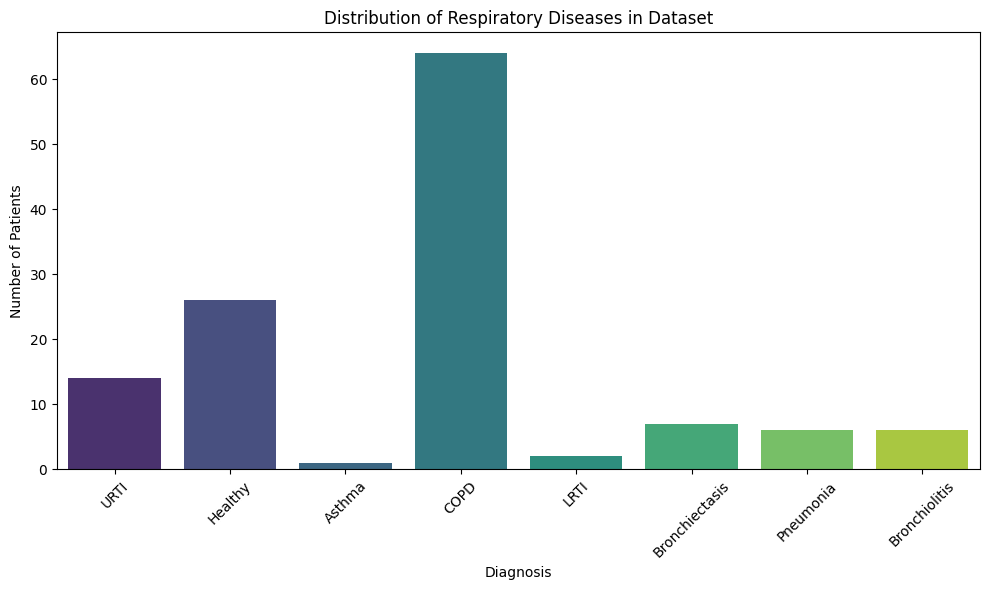

Total audio files found: 920


In [ ]:
## Data Exploration and Analysis

# 1. Load and explore the diagnosis data
# The CSV has no header, so we explicitly define the columns
diagnosis_df = pd.read_csv(diagnosis_csv, names=['Patient_ID', 'Diagnosis'])

plt.figure(figsize=(10, 6))
sns.countplot(x='Diagnosis', data=diagnosis_df, palette='viridis')
plt.title('Distribution of Respiratory Diseases in Dataset')
plt.ylabel('Number of Patients')
plt.xlabel('Diagnosis')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# 2. Explore Audio Files
# Grab all the .wav files from the directory
audio_files = [f for f in os.listdir(audio_dir) if f.endswith('.wav')]
print(f"Total audio files found: {len(audio_files)}")

# 3. Visualize a single audio file (Waveform and Spectrogram)
sample_file = os.path.join(audio_dir, audio_files[0])
y, sr = librosa.load(sample_file, sr=None) # Load with native sample rate

plt.figure(figsize=(14, 10))

# Plot the raw waveform (Amplitude over time)
plt.subplot(2, 1, 1)
librosa.display.waveshow(y, sr=sr, alpha=0.6)
plt.title(f'Waveform of {audio_files[0]}')
plt.xlabel('Time (s)')
plt.ylabel('Amplitude')

# Plot the Mel-Spectrogram (Frequency over time)
plt.subplot(2, 1, 2)
mel_spectrogram = librosa.feature.melspectrogram(y=y, sr=sr, n_mels=128, fmax=8000)
mel_spectrogram_db = librosa.power_to_db(mel_spectrogram, ref=np.max)
librosa.display.specshow(mel_spectrogram_db, sr=sr, x_axis='time', y_axis='mel', fmax=8000)
plt.colorbar(format='%+2.0f dB')
plt.title('Mel-Spectrogram (Visual representation of the audio)')

plt.tight_layout()
plt.show()

## Data Preprocessing

In [ ]:
## Data Preprocessing

def extract_mfcc_features(file_path, target_length=5):
    """
    Loads an audio file, pads/truncates it to the target length (in seconds),
    and extracts the mean of 40 MFCC features.
    """
    try:
        # Load audio, resampling to 22050 Hz for consistency
        y, sr = librosa.load(file_path, sr=22050)

        # Calculate target length in total samples
        target_samples = target_length * sr

        # Pad or truncate the audio signal so every file is the exact same shape
        if len(y) > target_samples:
            y = y[:target_samples]
        else:
            padding = target_samples - len(y)
            y = np.pad(y, (0, padding), 'constant')

        # Extract 40 MFCCs
        mfccs = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=40)

        # Average the MFCCs across the time axis to create a 1D feature array
        return np.mean(mfccs.T, axis=0)

    except Exception as e:
        print(f"Error parsing {file_path}: {e}")
        return None

features = []
labels = []

print("Extracting MFCC features from audio files. This may take a few minutes...")

# Iterate through all audio files
for file in tqdm(audio_files):
    # The filename format is: PatientID_RecordingIndex_ChestLocation_AcquisitionMode_Equipment.wav
    # We split by '_' and grab the first element to get the Patient ID
    patient_id = int(file.split('_')[0])

    # Look up the diagnosis for this specific patient
    patient_diagnosis = diagnosis_df[diagnosis_df['Patient_ID'] == patient_id]['Diagnosis'].values

    # If a diagnosis exists, process the audio file
    if len(patient_diagnosis) > 0:
        file_path = os.path.join(audio_dir, file)
        mfcc_data = extract_mfcc_features(file_path)

        if mfcc_data is not None:
            features.append(mfcc_data)
            labels.append(patient_diagnosis[0])

# Convert our lists into a structured Pandas DataFrame
X = np.array(features)
y = np.array(labels)

df_features = pd.DataFrame(X)
df_features['Label'] = y

print(f"Preprocessing complete! Feature matrix shape: {df_features.shape}")
display(df_features.head())

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.preprocessing import LabelEncoder
import numpy as np

# 1. Check class distribution and filter out classes with only 1 sample
# (Stratified splitting requires at least 2 samples per class)
label_counts = df_features['Label'].value_counts()
print("Original Class Distribution:\n", label_counts)

valid_labels = label_counts[label_counts >= 2].index
df_filtered = df_features[df_features['Label'].isin(valid_labels)]

print(f"\nFiltered out {len(df_features) - len(df_filtered)} samples belonging to classes with only 1 occurrence.")

# 2. Separate Features (X) and Target (y)
X = df_filtered.drop('Label', axis=1).values
y_text = df_filtered['Label'].values

# Encode text labels into numbers
le = LabelEncoder()
y = le.fit_transform(y_text)

# 3. Split the data (80% training, 20% testing)
# stratify=y ensures both sets have the same proportion of diseases
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(f"\nTraining data shape: {X_train.shape}")
print(f"Testing data shape: {X_test.shape}")

# 4. Initialize and train the Random Forest
# class_weight='balanced' forces the model to pay attention to minority classes
print("\nTraining the Random Forest model...")
rf_model = RandomForestClassifier(n_estimators=100, class_weight='balanced', random_state=42)
rf_model.fit(X_train, y_train)

# 5. Make predictions and evaluate
y_pred = rf_model.predict(X_test)

print("\n" + "="*40)
print("          CLASSIFICATION REPORT")
print("="*40)

# THE FIX: Explicitly define the label indices (0 through 6)
labels_index = np.arange(len(le.classes_))

# Pass labels_index to the classification report
print(classification_report(y_test, y_pred, labels=labels_index, target_names=le.classes_, zero_division=0))

# 6. Plot the Confusion Matrix
plt.figure(figsize=(10, 8))
# THE FIX: Pass labels_index to the confusion matrix as well
cm = confusion_matrix(y_test, y_pred, labels=labels_index)

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=le.classes_,
            yticklabels=le.classes_)
plt.title('Baseline Random Forest - Confusion Matrix')
plt.ylabel('Actual Diagnosis')
plt.xlabel('Predicted Diagnosis')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [ ]:
from imblearn.over_sampling import RandomOverSampler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

print("Original training data shape:", X_train.shape)

# 1. Balance the training data using Random Oversampling
ros = RandomOverSampler(random_state=42)
X_train_resampled, y_train_resampled = ros.fit_resample(X_train, y_train)

print("Balanced training data shape:", X_train_resampled.shape)
print("="*50)

# 2. Define the four models to benchmark
models = {
    "Logistic Regression": LogisticRegression(max_iter=2000, random_state=42),
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42),
    "Gradient Boosting": GradientBoostingClassifier(n_estimators=100, random_state=42),
    "SVM (RBF Kernel)": SVC(kernel='rbf', random_state=42)
}

trained_models = {}
predictions = {}
labels_index = np.arange(len(le.classes_))

# 3. Train and evaluate each model
for name, model in models.items():
    print(f"\nTraining {name}...")

    # Train on the BALANCED data
    model.fit(X_train_resampled, y_train_resampled)
    trained_models[name] = model

    # Predict on the UNTOUCHED test data
    y_pred = model.predict(X_test)
    predictions[name] = y_pred

    # Print results
    print(f"--- Results for {name} ---")
    print(f"Accuracy: {accuracy_score(y_test, y_pred):.4f}")
    print(classification_report(y_test, y_pred, labels=labels_index, target_names=le.classes_, zero_division=0))

# 4. Plot all Confusion Matrices side-by-side
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
axes = axes.ravel()

for idx, (name, y_pred) in enumerate(predictions.items()):
    cm = confusion_matrix(y_test, y_pred, labels=labels_index)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Greens', ax=axes[idx],
                xticklabels=le.classes_, yticklabels=le.classes_)
    axes[idx].set_title(f'{name}')
    axes[idx].set_ylabel('Actual')
    axes[idx].set_xlabel('Predicted')
    axes[idx].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

## Step 1: The Advanced Feature Extraction

In [ ]:
import librosa
import numpy as np
import pandas as pd
import os
from tqdm.notebook import tqdm

print("Initializing Advanced Feature Extraction...")

def extract_advanced_features(file_path, target_length=5):
    """Extracts MFCCs, Chroma, Spectral Contrast, and Zero-Crossing Rate."""
    try:
        y, sr = librosa.load(file_path, sr=22050)
        target_samples = target_length * sr

        # Pad or truncate
        if len(y) > target_samples:
            y = y[:target_samples]
        else:
            padding = target_samples - len(y)
            y = np.pad(y, (0, padding), 'constant')

        # 1. MFCCs (40 features) - General vocal tract shape
        mfccs = np.mean(librosa.feature.mfcc(y=y, sr=sr, n_mfcc=40).T, axis=0)

        # 2. Chroma (12 features) - Pitch class profiles
        chroma = np.mean(librosa.feature.chroma_stft(y=y, sr=sr).T, axis=0)

        # 3. Spectral Contrast (7 features) - Difference between peaks and valleys
        contrast = np.mean(librosa.feature.spectral_contrast(y=y, sr=sr).T, axis=0)

        # 4. Zero-Crossing Rate (1 feature) - Good for crackles/percussive sounds
        zcr = np.mean(librosa.feature.zero_crossing_rate(y=y).T, axis=0)

        # Stack them all together into a 60-feature array
        return np.hstack((mfccs, chroma, contrast, zcr))

    except Exception as e:
        return None

# Re-extract the features (using the audio_files and diagnosis_df from your earlier setup)
advanced_features = []
advanced_labels = []

print("Extracting 60 features per file. This will take a few minutes...")
for file in tqdm(audio_files):
    patient_id = int(file.split('_')[0])
    patient_diagnosis = diagnosis_df[diagnosis_df['Patient_ID'] == patient_id]['Diagnosis'].values

    if len(patient_diagnosis) > 0:
        file_path = os.path.join(audio_dir, file)
        feature_data = extract_advanced_features(file_path)

        if feature_data is not None:
            advanced_features.append(feature_data)
            advanced_labels.append(patient_diagnosis[0])

# Build the new DataFrame
X_adv = np.array(advanced_features)
y_adv_text = np.array(advanced_labels)

df_adv = pd.DataFrame(X_adv)
df_adv['Label'] = y_adv_text

print(f"Advanced Preprocessing complete! New Feature matrix shape: {df_adv.shape}")

## Step 2: The Hyperparameter Hunt

In [ ]:
from sklearn.model_selection import GroupShuffleSplit
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.preprocessing import LabelEncoder
from imblearn.over_sampling import RandomOverSampler
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd

print("1. Preparing Data and Tracking Patient IDs...")
patient_groups = []
valid_indices = []

# Get valid labels (removing 1-sample classes like Asthma)
label_counts = df_adv['Label'].value_counts()
valid_labels = label_counts[label_counts >= 2].index

for idx, row in df_adv.iterrows():
    if row['Label'] in valid_labels:
        valid_indices.append(idx)
        # Extract patient ID from the original audio_files list
        patient_id = int(audio_files[idx].split('_')[0])
        patient_groups.append(patient_id)

# Filter the dataset
df_adv_filtered = df_adv.iloc[valid_indices]
X_final = df_adv_filtered.drop('Label', axis=1).values
y_final_text = df_adv_filtered['Label'].values
groups = np.array(patient_groups)

# Encode text labels into numbers
le = LabelEncoder()
y_final = le.fit_transform(y_final_text)

print("2. Performing GroupShuffleSplit (Preventing Data Leakage)...")
# Split by Patient ID!
gss = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42)

for train_idx, test_idx in gss.split(X_final, y_final, groups):
    X_train_adv, X_test_adv = X_final[train_idx], X_final[test_idx]
    y_train_adv, y_test_adv = y_final[train_idx], y_final[test_idx]

print(f"Grouped Training data shape: {X_train_adv.shape}")
print(f"Grouped Testing data shape: {X_test_adv.shape}")

print("\n3. Balancing the Training Data...")
# Apply RandomOverSampler ONLY to the training data
ros = RandomOverSampler(random_state=42)
X_train_resampled, y_train_resampled = ros.fit_resample(X_train_adv, y_train_adv)
print(f"Balanced training data shape: {X_train_resampled.shape}")

print("\n4. Training the Ultimate Gradient Boosting Model...")
# Re-using the winning hyperparameters we found earlier!
best_gb = GradientBoostingClassifier(
    n_estimators=200,
    learning_rate=0.1,
    max_depth=7,
    subsample=0.8,
    random_state=42
)

best_gb.fit(X_train_resampled, y_train_resampled)

# 5. Final Evaluation
y_pred_adv = best_gb.predict(X_test_adv)
labels_index = np.arange(len(le.classes_))

print("\n" + "="*50)
print("  SCIENTIFICALLY VALID CLASSIFICATION REPORT")
print("="*50)
print(classification_report(y_test_adv, y_pred_adv, labels=labels_index, target_names=le.classes_, zero_division=0))

# Plot Final Confusion Matrix
plt.figure(figsize=(10, 8))
cm_adv = confusion_matrix(y_test_adv, y_pred_adv, labels=labels_index)
sns.heatmap(cm_adv, annot=True, fmt='d', cmap='Purples',
            xticklabels=le.classes_, yticklabels=le.classes_)
plt.title('Tuned Gradient Boosting - Grouped Split (No Leakage)')
plt.ylabel('Actual Diagnosis')
plt.xlabel('Predicted Diagnosis')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()